# Mapping the Potential Destructive Power of Wildfires Using Machine Learning
---
## Module 8: *Evaluation and Visualization*
##### Version Number: 3.0
---
### Contents  
> 1. *Build Models*
> 2. *Train Models*
> 3. *Generate Predictions*
> 4. *Geospatial Visualization*
> 5. *Export File*
---
### Notes
This section applies the trained models to predict wildfire severity in real-world scenarios including
- #### Palisades Fire (January 07, 2025)  

It evaluates and compare the performance of three classification models:
- **XGBoost**
- **Random Forest**
- **Neural Network**
---
### Inputs
- `X.csv` Model data
- `y.csv` Target data
- `details.csv` details reguarding data
- `pal_X`,`pal_details` data for 2025 predictions
- `best_strategy` best class balancing strategies calculated from module 06
- `model_parameters` optimum parameters as determined by module 07

---
### Outputs  
- `predictions.csv` Dataset containing prediction models composed of a categorical prediction 0,1,2 to be used for interpolation in ArcGIS.
---
### User Created Dependencies  

In [1]:
# Add the parent directory to the system path so "src" can be found
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

# user built utilities
from src.plot_utils import plot_map

from src.model_utils import apply_balancing

---
### Third Party Dependencies

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import RidgeClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, r2_score

# Geospatial libraries
import geopandas as gpd
from shapely.geometry import Point

from datetime import timedelta
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

---
### Global Constants

In [3]:
# first day to analyze in weather dataset
FIRST_DATE = pd.to_datetime('2018-01-01').date()

# last day to analyze in weather dataset
LAST_DATE = pd.to_datetime('2024-12-31').date()

---

### Load Data

In [4]:
X = pd.read_csv('../data/processed/X_scaled.csv')
y = pd.read_csv('../data/processed/y_reduced.csv').squeeze()  # Load as Series
details = pd.read_csv('../data/processed/details.csv')

best_strategy = pd.read_csv('../data/processed/best_strategy.csv')
model_parameters = pd.read_csv('../data/processed/model_parameters.csv', index_col=0)

pal_details = pd.read_csv('../data/processed/pal_details.csv')
pal_X = pd.read_csv('../data/processed/pal_X.csv')
details['Date'] = pd.to_datetime(details['Date']).dt.date

In [5]:
y.value_counts()

Target
0    50000
1    43005
2    13773
Name: count, dtype: int64

## 1. Build Models

In [6]:
model_parameters = pd.read_csv('../data/processed/model_parameters.csv', index_col=0)

In [7]:
RF_parameters = model_parameters.loc['RandomForest'].dropna().to_dict()
XGB_parameters = model_parameters.loc['XGBoost'].dropna().to_dict()
NN_parameters = model_parameters.loc['NN'].dropna().to_dict()
optimal_learning_rate = XGB_parameters['learning_rate']

NN_learning_rate = NN_parameters['learning_rate']
NN_learning_rate_init = NN_parameters['learning_rate_init']
NN_alpha = NN_parameters['alpha']

In [8]:
# Helper function to convert to int if possible
def convert_to_int(d):
    return {k: int(float(v)) if str(v).replace('.', '', 1).isdigit() else v for k, v in d.items()}

RF_parameters = convert_to_int(RF_parameters)
XGB_parameters = convert_to_int(XGB_parameters)
NN_parameters = convert_to_int(NN_parameters)

XGB_parameters['learning_rate'] = optimal_learning_rate
NN_parameters['learning_rate'] = NN_learning_rate
NN_parameters['learning_rate_init'] = NN_learning_rate_init
NN_parameters['hidden_layer_sizes'] = (128,64,32)
NN_parameters['alpha'] = NN_alpha

In [9]:
display(RF_parameters)
display(XGB_parameters)
display(NN_parameters)

{'n_estimators': 100,
 'max_depth': 20,
 'min_samples_split': 5,
 'max_features': 'sqrt',
 'class_weight': 'balanced'}

{'n_estimators': 50,
 'max_depth': 6,
 'objective': 'multi:softmax',
 'num_class': 3,
 'learning_rate': '0.3',
 'verbosity': 0}

{'learning_rate': 'constant',
 'hidden_layer_sizes': (128, 64, 32),
 'activation': 'identity',
 'solver': 'adam',
 'alpha': 0.01,
 'batch_size': 'auto',
 'learning_rate_init': 0.0005,
 'max_iter': 500,
 'early_stopping': True,
 'random_state': 14,
 'verbose': False}

In [10]:
# Build Final tuned models
optimum_xgb_model = xgb.XGBClassifier(**XGB_parameters)
optimum_rf = RandomForestClassifier(**RF_parameters)
optimum_nn_model = MLPClassifier(**NN_parameters)

## 2. Train Models

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)

In [12]:
X_train_balanced, y_train_balanced = apply_balancing('RF', best_strategy, X_train, y_train)
optimum_rf.fit(X_train_balanced, y_train_balanced)

X_train_balanced, y_train_balanced = apply_balancing('NN', best_strategy, X_train, y_train)
optimum_nn_model.fit(X_train_balanced, y_train_balanced)

X_train_balanced, y_train_balanced = apply_balancing('XGB', best_strategy, X_train, y_train)
optimum_xgb_model.set_params(verbosity=0)
optimum_xgb_model.fit(X_train_balanced, y_train_balanced)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate='0.3', max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None, num_class=3,
              num_parallel_tree=None, ...)

In [13]:
# Create a Series for easy sorting
importances = pd.Series(optimum_rf.feature_importances_, index=X.columns)

# Get top 10
top10 = importances.sort_values(ascending=False).head(10)

top10.to_frame(name="Random Forest Top 10 Importance")

,Random Forest Top 10 Importance
Year,0.144948
Total_Housing,0.041555
2-Year Avg Fires,0.040784
Total_Population,0.036868
Housing_Density,0.035013
Region_ID,0.032556
Population_Density,0.030182
Intermix_Area,0.029940
Palmer Drought Severity Index,0.027908
Influence_Area,0.026186


In [14]:
# Create a Series for easy sorting
importances = pd.Series( optimum_xgb_model.feature_importances_, index=X.columns)

# Get top 10
top10 = importances.sort_values(ascending=False).head(10)

top10.to_frame(name="XGB Top 10 Importance")

,XGB Top 10 Importance
Total_Housing,0.105820
Year,0.099056
Interface_Area,0.088701
Region_ID,0.086055
Total_Population,0.070080
Energy Release Component,0.055237
Influence_Area,0.054375
Intermix_Area,0.035768
Month,0.032724
Mean Income,0.030948


In [15]:
def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    print(f"Evaluation for {name}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.3f}")
    print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.3f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred, average='weighted'):.3f}")
    print("---- Classification Report ----")
    print(classification_report(y_test, y_pred))
    print("\n")

In [16]:
evaluate_model(optimum_xgb_model, X_test, y_test, "XGBoost")

Evaluation for XGBoost
Accuracy:  0.756
Precision: 0.756
Recall:    0.756
F1 Score:  0.756
---- Classification Report ----
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      9982
           1       0.75      0.74      0.74      8545
           2       0.65      0.64      0.64      2829

    accuracy                           0.76     21356
   macro avg       0.73      0.73      0.73     21356
weighted avg       0.76      0.76      0.76     21356





In [17]:
evaluate_model(optimum_rf, X_test, y_test, "Random Forest")

Evaluation for Random Forest
Accuracy:  0.754
Precision: 0.760
Recall:    0.754
F1 Score:  0.756
---- Classification Report ----
              precision    recall  f1-score   support

           0       0.80      0.80      0.80      9982
           1       0.77      0.71      0.74      8545
           2       0.59      0.73      0.65      2829

    accuracy                           0.75     21356
   macro avg       0.72      0.75      0.73     21356
weighted avg       0.76      0.75      0.76     21356





In [18]:
evaluate_model(optimum_nn_model, X_test, y_test, "Neural Network")

Evaluation for Neural Network
Accuracy:  0.482
Precision: 0.618
Recall:    0.482
F1 Score:  0.503
---- Classification Report ----
              precision    recall  f1-score   support

           0       0.66      0.60      0.63      9982
           1       0.71      0.30      0.42      8545
           2       0.20      0.61      0.30      2829

    accuracy                           0.48     21356
   macro avg       0.52      0.50      0.45     21356
weighted avg       0.62      0.48      0.50     21356





## 3. Generate Predictions

In [19]:
# Palisades Fire (January 2025)
pal_xgb_predictions = pd.DataFrame(optimum_xgb_model.predict(pal_X))
pal_xgb_predictions.value_counts()

0
0    3453
1     465
2      61
Name: count, dtype: int64

In [20]:
pal_rf_predictions = pd.DataFrame(optimum_rf.predict(pal_X))
pal_rf_predictions.value_counts()

0
0    3518
1     460
2       1
Name: count, dtype: int64

In [21]:
pal_nn_predictions = pd.DataFrame(optimum_nn_model.predict(pal_X))
pal_nn_predictions.value_counts()

0
0    2208
2    1403
1     368
Name: count, dtype: int64

### 3.1 Save Predictions for plotting

In [22]:
pal_details = pal_details.copy()

pal_details['Prediction XGB'] = pal_xgb_predictions[0].values
pal_details['Prediction RF']  = pal_rf_predictions[0].values
pal_details['Prediction NN']  = pal_nn_predictions[0].values

In [23]:
pal_specific_date = pd.to_datetime('2025-01-07').date()
pal_details['Date'] = pd.to_datetime(pal_details['Date']).dt.date

In [24]:
# Create geometry from lat/lon
pal_geometry = [Point(xy) for xy in zip(pal_details['Sample_Longitude'], pal_details['Sample_Latitude'])]

# Convert to GeoDataFrames
pal_gdf = gpd.GeoDataFrame(pal_details, geometry=pal_geometry, crs="EPSG:4326")

In [25]:
pal_predictions = pal_gdf[pal_gdf['Date'] == pal_specific_date]

## 2 Geospatial Visualization of Model Predictions

This section visualizes wildfire severity predictions made by each model on specific dates during the Palisades Fire (Jan 2025) and the Dixie Fire (July 2021).

In [26]:
pal_predictions.rename(columns={'Sample_Longitude': 'Longitude'}, inplace=True)
pal_predictions.rename(columns={'Sample_Latitude': 'Latitude'}, inplace=True)

C:\Users\dusti\AppData\Local\Temp\ipykernel_17796\1867091396.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pal_predictions.rename(columns={'Sample_Longitude': 'Longitude'}, inplace=True)
C:\Users\dusti\AppData\Local\Temp\ipykernel_17796\1867091396.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pal_predictions.rename(columns={'Sample_Latitude': 'Latitude'}, inplace=True)


### 2.1 Palisades Predictions 01072025

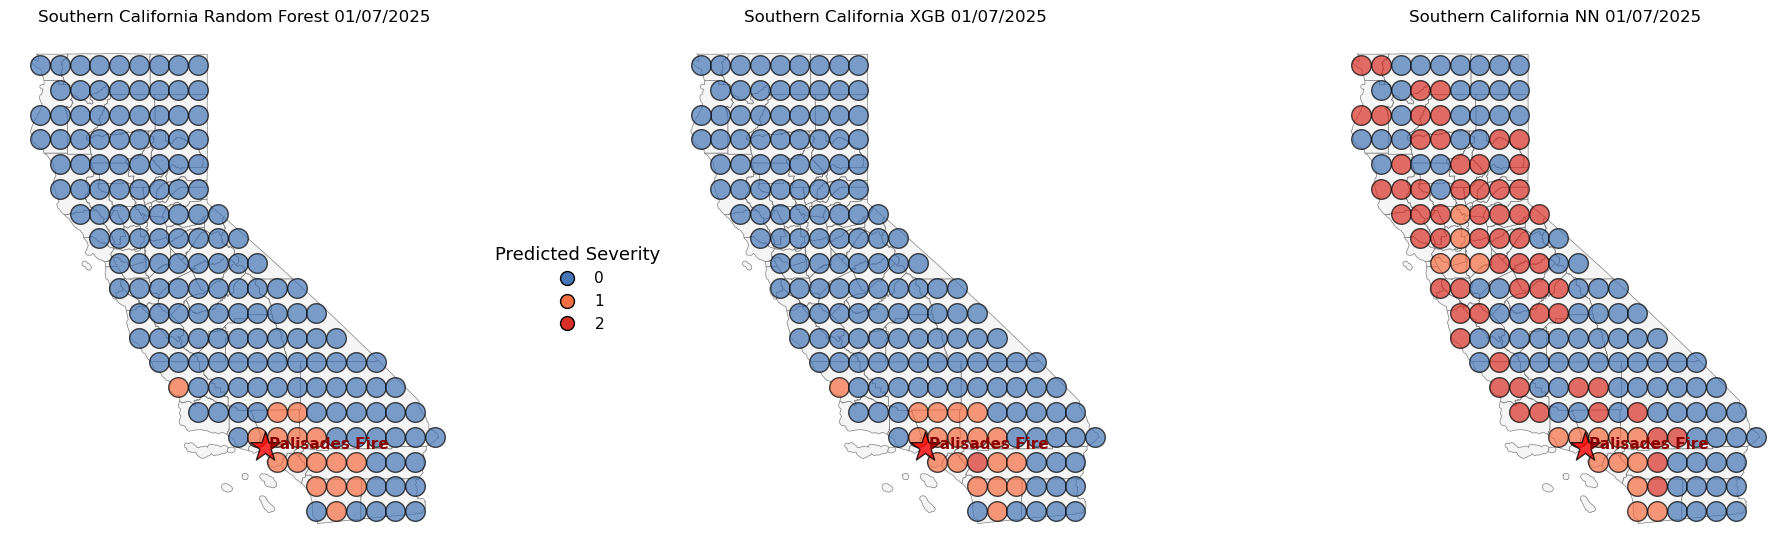

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# Plot into each subplot by passing in the axis
plot_map(pal_predictions, 'Prediction RF', 'Palisades', ax=axes[0])
plot_map(pal_predictions, 'Prediction XGB', 'Palisades', ax=axes[1])
plot_map(pal_predictions, 'Prediction NN', 'Palisades', ax=axes[2])

# Set titles if plot_map doesn't do it
axes[0].set_title('Southern California Random Forest 01/07/2025')
axes[1].set_title('Southern California XGB 01/07/2025')
axes[2].set_title('Southern California NN 01/07/2025')

plt.tight_layout()

#plt.savefig("../plots/Palisades_predictions.png", dpi=600)

### Interpolation

<img src="../data/maps/IDW_RF.jpg" width="600">

## 3. Export File

In [28]:
pal_gdf.to_csv('../data/processed/predictions.csv', index=False)